# Masking into MERRA-2 Datasets

A little notebook to showcase how I might start using my database to mask into MERRA-2

In [1]:
import pandas as pd
import xarray as xr
import numpy as np
import os
from pathlib import Path
import seaborn as sns

from netrc import netrc
import xarray as xr
import boto3
from subprocess import Popen
from getpass import getpass

ModuleNotFoundError: No module named 'boto3'

In [2]:
np.version.version

'2.0.1'

In [86]:
# load up yearly datasets

scratch_path = '/scratch/users/butlerj/extreme_antarctic_ars/dataframes/'
fnames = os.listdir(scratch_path)
df_list = []

for fname in fnames:
    df_list.append(pd.read_pickle(scratch_path + fname))
    
dataframe = pd.concat(df_list)

In [127]:
dataframe.memory_usage()

Index             64656
data_array        64656
is_landfalling     8082
max_area          64656
mean_area         64656
duration          64656
start_date        64656
end_date          64656
dtype: int64

In [87]:
# load up relevant MERRA-2 datasets
grid_areas = xr.open_dataset('/accounts/grad/butlerj/extreme_antarctic_ARs/data/area/MERRA2_gridarea.nc')
grid_areas = grid_areas.sel(lat=slice(-86, -39)).cell_area

In [91]:
def compute_max_area(ar_da):
    da = ar_da.rename({'lats':'lat', 'lons':'lon'})
    grid_area_storm = grid_areas.sel(lat=da.lat, lon=da.lon)
    max_area = float(da.dot(grid_area_storm).max().values/(1000**2))
    return max_area

def compute_mean_area(ar_da):
    da = ar_da.rename({'lats':'lat', 'lons':'lon'})
    grid_area_storm = grid_areas.sel(lat=da.lat, lon=da.lon)
    mean_area = float(da.dot(grid_area_storm).mean().values/(1000**2))
    return mean_area

def compute_duration(ar_da):
    days = (ar_da.time.max() - ar_da.time.min()).values.astype('timedelta64[h]').astype(int) + np.timedelta64(3, 'h')
    return days

def add_start_date(ar_da):
    start = ar_da.time.min().values
    return start

def add_end_date(ar_da):
    end = ar_da.time.max().values
    return end

In [94]:
dataframe['max_area'] = dataframe['data_array'].apply(compute_max_area)
dataframe['mean_area'] = dataframe['data_array'].apply(compute_mean_area)
dataframe['duration'] = dataframe['data_array'].apply(compute_duration)
dataframe['start_date'] = dataframe['data_array'].apply(add_start_date)
dataframe['end_date'] = dataframe['data_array'].apply(add_end_date)

In [119]:
attr_df = dataframe[['max_area', 'mean_area', 'duration', 'start_date', 'end_date', 'is_landfalling']]

In [120]:
attr_df = attr_df.sort_values(by='start_date')

<Axes: xlabel='start_date', ylabel='mean_area'>

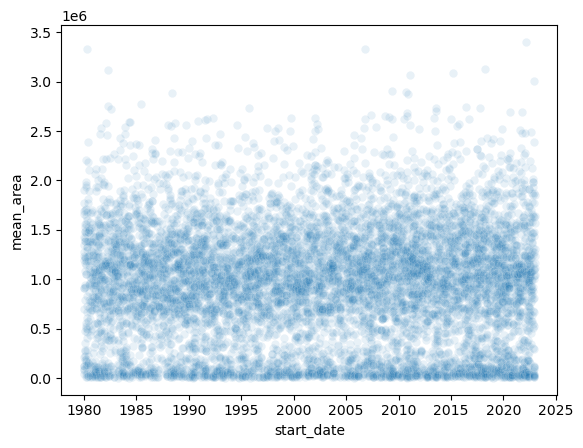

In [121]:
sns.scatterplot(data=attr_df, x='start_date', y='mean_area', alpha=0.1)

<Axes: xlabel='start_date', ylabel='mean_area'>

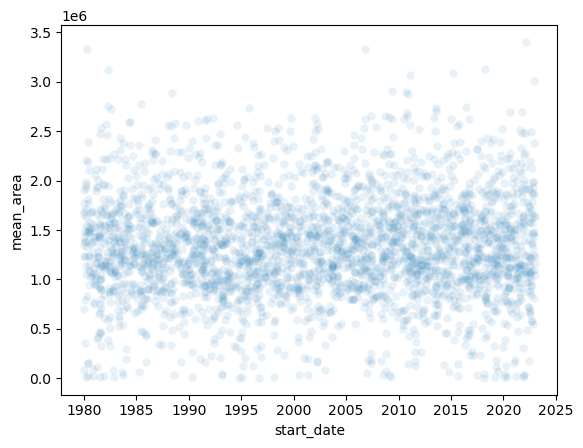

In [124]:
sns.scatterplot(data=attr_df[attr_df['is_landfalling']], x='start_date', y='mean_area', alpha=0.1)

<Axes: xlabel='start_date', ylabel='max_area'>

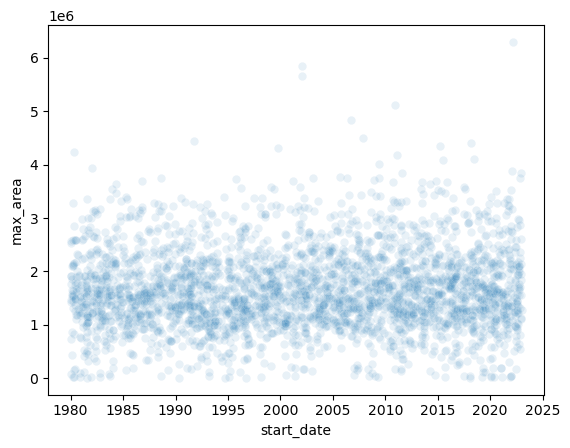

In [125]:
sns.scatterplot(data=attr_df[attr_df['is_landfalling']], x='start_date', y='max_area', alpha=0.1)

<Axes: xlabel='start_date', ylabel='Count'>

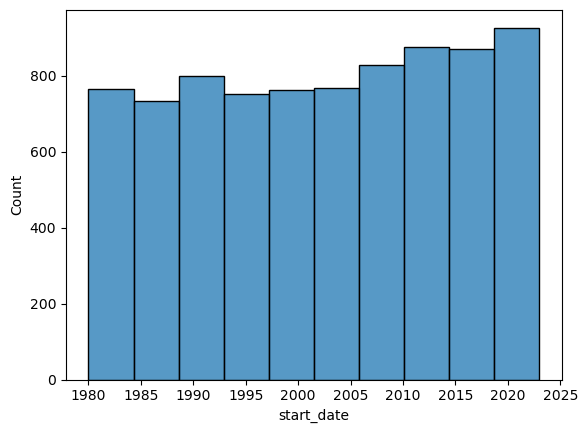

In [122]:
sns.histplot(data=attr_df, x='start_date', bins=10)

<Axes: xlabel='start_date', ylabel='Count'>

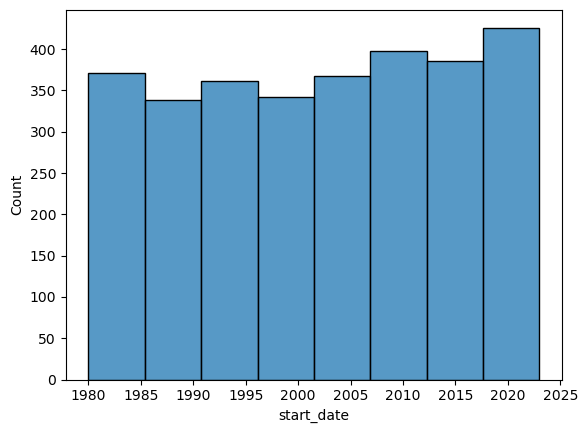

In [126]:
sns.histplot(data=attr_df[attr_df['is_landfalling']], x='start_date', bins=8)